# Model training

Let's see some ways we can use the normal equation (OLS estimation) to compute the linear model that interpolates better the training data.
First, we generate some random data:

# Linear Regression

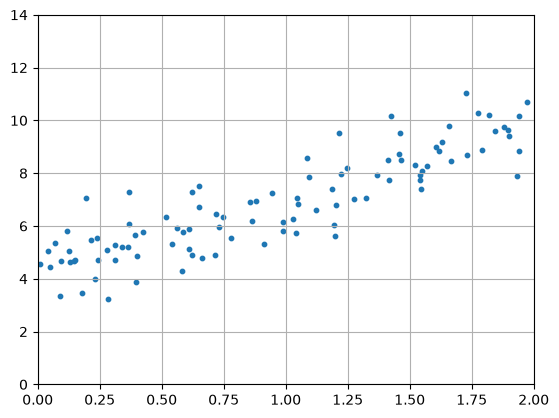

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
m = 100
X = 2 * np.random.rand(m, 1)
y = 4 + 3*X + np.random.randn(m, 1)

plt.scatter(x=X, y=y, s=10)
plt.xlim(0.0, 2.0)
plt.ylim(0.0, 14.0)
plt.grid()
plt.show()

Now we can derive the OLS estimator using linear algebra from the normal equation. Remember. Since the model is $\hat{y}=\beta_0 + \beta_1 \cdot \textbf{X} + \epsilon$ the $\beta_0$ parameter must be multiplied by 1, in the full matrix form, so we must add a 1 to the $X$ matrix

In [2]:
from sklearn.preprocessing import add_dummy_feature

X_b = add_dummy_feature(X) # adds x0 = 1b
theta_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
print(f"OLS estimator value: {theta_best}")

OLS estimator value: [[4.21509616]
 [2.77011339]]


The actual paremeters were 4 and 3, so close enough. Now we can make predictions with this:

In [3]:
X_new = np.array([[0], [2]])
X_new_b = add_dummy_feature(X_new)
y_predict = X_new_b @ theta_best
print(f"Predicted value: {y_predict}")

Predicted value: [[4.21509616]
 [9.75532293]]


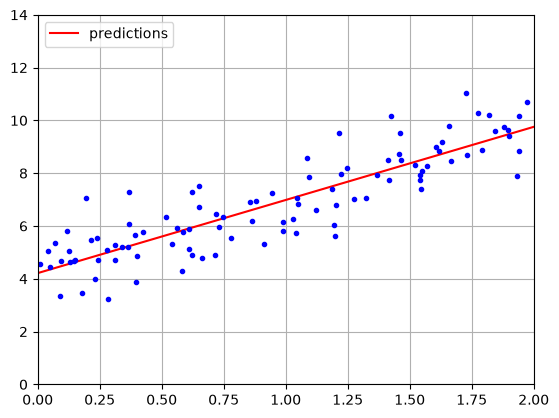

In [4]:
plt.plot(X_new, y_predict, "r-", label="predictions")
plt.plot(X, y, "b.")
plt.xlim(0.0, 2.0)
plt.ylim(0.0, 14.0)
plt.grid()
plt.legend(loc="upper left")
plt.show()

You can also use scikit learn's `LinearRegression()` which does this for you. 

In [5]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X, y)
lin_reg.intercept_, lin_reg.coef_

(array([4.21509616]), array([[2.77011339]]))

In [6]:
lin_reg.predict(X_new)

array([[4.21509616],
       [9.75532293]])

Same values! Notice that this algorithm of *least squares* is what happens under the hood. You can get it from numpy (which basically computes the **SVD** or the Moore-Penrose inverse $\textbf{X}^+$)

In [7]:
best_svd, residuals, rank, s = np.linalg.lstsq(X, y, rcond=1e-6)
print(f"solution: {best_svd}")
print(f"residuals: {residuals}")
print(f"rank: {rank}")
print(f"singular values: {s}")

solution: [[5.98027553]]
residuals: [584.94552486]
rank: 1
singular values: [11.1118834]


Or compute the pseudoinverse with numpy:

In [8]:
np.linalg.pinv(X_b) @ y

array([[4.21509616],
       [2.77011339]])

We can implement the same thing with **Batch Gradient Descent**:

In [9]:
eta = 0.1
epochs = 1000
m = len(X_b)
theta = np.random.rand(2, 1)

for epoch in range(epochs):
    gradients = 2 / m * X_b.T @ (X_b @ theta - y)
    theta = theta - eta * gradients

theta

array([[4.21509616],
       [2.77011339]])

Or with **Stochastic Gradient Descent**:

In [10]:
epochs = 50
t0, t1 = 5, 50

def learning_schedule(t):
    return t0 / (t + t1)

theta = np.random.randn(2, 1)

for epoch in range(epochs):
    for iteration in range(m):
        random_index = np.random.randint(m)
        xi = X_b[random_index : random_index + 1]
        yi = y[random_index : random_index + 1]
        gradients = 2 * xi.T @ (xi @ theta - yi) # for SGD do not divide by m
        eta = learning_schedule(epoch * m + iteration)
        theta = theta - eta * gradients

theta

array([[4.18475289],
       [2.73036719]])

Or with sklearn:

In [11]:
from sklearn.linear_model import SGDRegressor

sdg_reg = SGDRegressor(max_iter=1000, n_iter_no_change=100, eta0=0.01, 
                       penalty=None, tol=1e-5)
sdg_reg.fit(X, y.ravel())
sdg_reg.intercept_, sdg_reg.coef_

(array([4.21495496]), array([2.77030722]))

# Polynomial Regression

What if the data is more complex than a straight line? You could add powers of each feature as a new feature, then train a linear model on this extended set of features.
First, we generate some non-linear data:

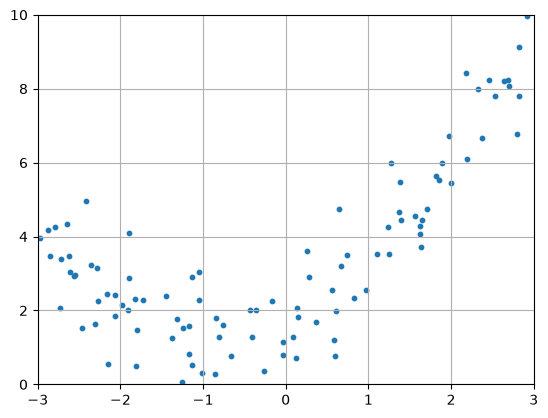

In [12]:
np.random.seed(42)
m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X ** 2 + X + 2 + np.random.randn(m, 1)
plt.scatter(x=X, y=y, s=10)
plt.xlim(-3.0, 3.0)
plt.ylim(0.0, 10.0)
plt.grid()
plt.show()

Now we import the square of each feature to each feature itself:

In [13]:
from sklearn.preprocessing import PolynomialFeatures

poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)
X_poly[0], X[0]

(array([-0.75275929,  0.56664654]), array([-0.75275929]))

In [14]:
lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)
lin_reg.intercept_, lin_reg.coef_

(array([1.78134581]), array([[0.93366893, 0.56456263]]))

Basically the model finds a model which is: $\hat{y} = 0.56x_1^2 + 0.93x_0 + 1.78$, which is not that far from reality.

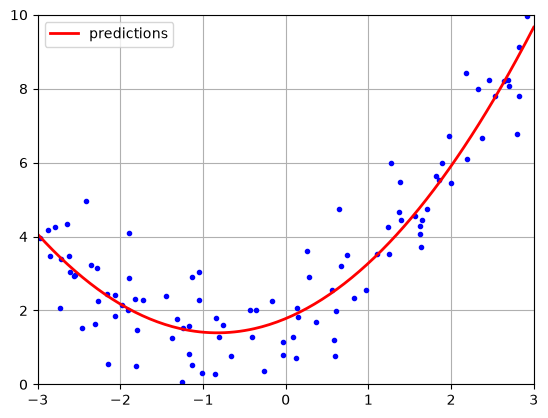

In [15]:
X_grid = np.linspace(-3, 3, 200).reshape(-1, 1)
X_grid_poly = poly_features.transform(X_grid)

y_grid_predict = lin_reg.predict(X_grid_poly)

plt.plot(X, y, "b.")
plt.plot(X_grid, y_grid_predict, color="red", linewidth=2, label="predictions")
plt.grid()
plt.xlim(-3.0, 3.0)
plt.legend(loc="upper left")
plt.ylim(0.0, 10.0)
plt.show()

If you want to cross validate this, you could use `learning_curve()` which basically does cv. It trains the model on growing subsets of the training set, but if the model supports incremental learning (has `partial_fit` or `warm_start`) you can set `exploit_incremental_learning=True`and it will train it incrementally.

In [16]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(LinearRegression(), X, y, train_sizes=np.linspace(0.01, 1.0, 40), cv=5, scoring="neg_root_mean_squared_error", n_jobs=2)
train_errors, test_errors = -train_scores.mean(axis=1), -test_scores.mean(axis=1)

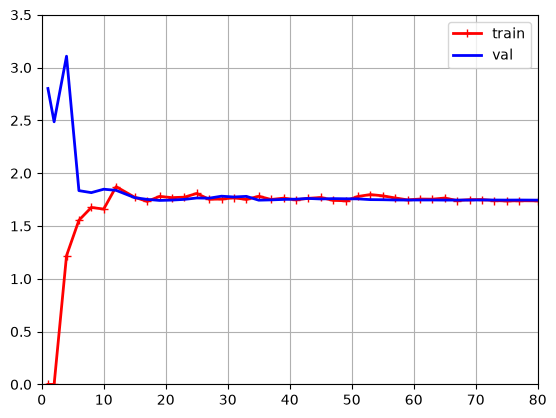

In [17]:
plt.plot(train_sizes, train_errors, "r-+", linewidth=2, label="train")
plt.plot(train_sizes, test_errors, "b-", linewidth=2, label="val")
plt.xlim(0.0, 80.0)
plt.ylim(0.0, 3.5)
plt.grid()
plt.legend(loc="upper right")
plt.show()

The model is underfitting:
- training error high
- validation error high
**Remember**: if a model is underfitting, training on more data does NOT solve the issue. The solution is to choose a more complex model or come up with better features.

In [18]:
from sklearn.pipeline import make_pipeline

polynomial_regression = make_pipeline(
    PolynomialFeatures(degree=10, include_bias=False),
    LinearRegression()
)

train_sizes, train_scores, test_scores = learning_curve(polynomial_regression, X, y, train_sizes=np.linspace(0.01, 1.0, 40), cv=5, scoring="neg_root_mean_squared_error")
train_errors, test_errors = -train_scores.mean(axis=1), -test_scores.mean(axis=1)

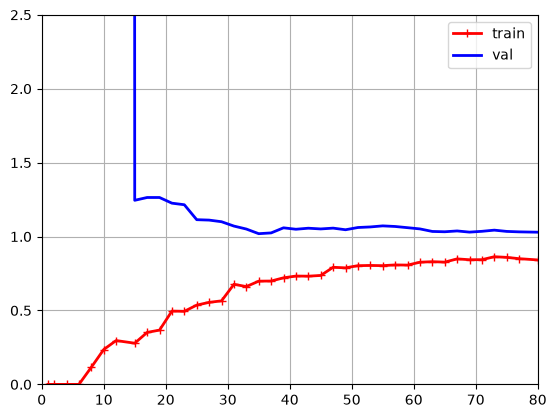

In [19]:
plt.plot(train_sizes, train_errors, "r-+", linewidth=2, label="train")
plt.plot(train_sizes, test_errors, "b-", linewidth=2, label="val")
plt.xlim(0.0, 80.0)
plt.ylim(0.0, 2.5)
plt.grid()
plt.legend(loc="upper right")
plt.show()

The model performs better on training data than on validation data, therefore it is overfitting slightly. With a much larger dataset the bridge between the two would probably fade.

# Regularized Models

## Ridge Regression

We can apply Ridge Regression using the matrix factorization technique by Andrè-Louis Cholesky:

In [20]:
from sklearn.linear_model import Ridge

ridge_reg = Ridge(alpha=0.1, solver='cholesky')
ridge_reg.fit(X, y)
ridge_reg.predict([[1.5]])

array([4.82899748])

and with SGD we can just apply L2 regularization:

In [21]:
from sklearn.linear_model import SGDRegressor

sgd_reg = SGDRegressor(penalty='l2', alpha=0.1 / m, tol=None, max_iter=1000, eta0=0.01, random_state=42)
sgd_reg.fit(X, y.ravel())
sgd_reg.predict([[1.5]])

array([4.82830117])

## Lasso Regression

Same thing:

In [22]:
from sklearn.linear_model import Lasso

lasso_reg = Lasso(alpha=0.1)
lasso_reg.fit(X, y)
lasso_reg.predict([[1.5]])

array([4.77621741])

In [23]:
sgd_reg = SGDRegressor(penalty="l1", alpha=0.1)
sgd_reg.fit(X, y.ravel())
sgd_reg.predict([[1.5]])

array([4.74753524])

## Early Stopping

Here is a basic implementation of it:

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error
from copy import deepcopy

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.1, random_state=42)


preprocessing = make_pipeline(PolynomialFeatures(degree=90, include_bias=False),
                              StandardScaler())

X_train_preprocessed = preprocessing.fit_transform(X_train)
X_val_preprocessed = preprocessing.transform(X_val)
sgd_reg = SGDRegressor(penalty=None, eta0=0.002, random_state=42)
epochs = 500
best_valid_rmse = float('inf')
best_model = None

for epoch in range(epochs):
    sgd_reg.partial_fit(X_train_preprocessed, y_train.ravel())
    y_pred = sgd_reg.predict(X_val_preprocessed)
    error = root_mean_squared_error(y_val, y_pred)

    if (epoch + 1) % 100 == 0:
        print(f"Epoch: {epoch + 1} | error: {error} | best error: {best_valid_rmse}")

    if error < best_valid_rmse:
        best_valid_rmse = error
        best_model = deepcopy(sgd_reg)

Epoch: 100 | error: 0.9821339903990368 | best error: 0.9867716549885861
Epoch: 200 | error: 0.797008578384154 | best error: 0.797565166578606
Epoch: 300 | error: 0.7751988050124012 | best error: 0.7752325720348956
Epoch: 400 | error: 0.7773766038692165 | best error: 0.7748735333745705
Epoch: 500 | error: 0.7827069394511152 | best error: 0.7748735333745705


# Logistic Regression

Let's build a classifier for Iris:

In [34]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
list(iris)

['data',
 'target',
 'frame',
 'target_names',
 'DESCR',
 'feature_names',
 'filename',
 'data_module']

In [35]:
iris.data.head(3)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2


In [36]:
iris.target.head(3)

0    0
1    0
2    0
Name: target, dtype: int64

We split the data and train a logistic regression model on the training set:

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X = iris.data[["petal width (cm)"]].values
y = iris.target_names[iris.target]  == 'virginica'
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

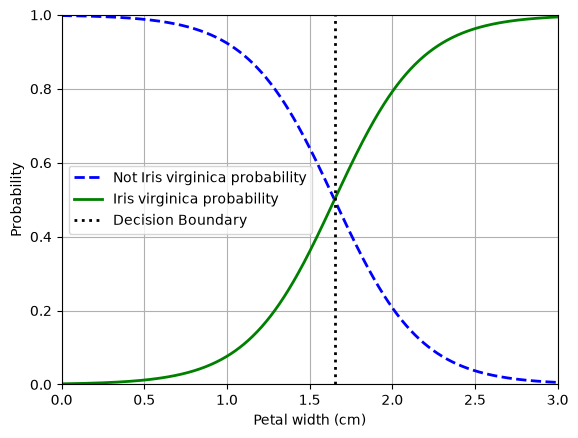

In [40]:
X_new = np.linspace(0, 3, 1000).reshape(-1, 1)
y_probs = log_reg.predict_proba(X_new) # return [[P(0), P(1)], ....]
decision_boundary = X_new[y_probs[:, 1] >= 0.5][0, 0] # take threshold for which predictions become true

plt.plot(X_new, y_probs[:, 0], "b--", linewidth=2, label="Not Iris virginica probability")
plt.plot(X_new, y_probs[:, 1], "g-", linewidth=2, label="Iris virginica probability")
plt.plot([decision_boundary, decision_boundary], [0, 1], "k:", linewidth=2, label="Decision Boundary")
plt.ylim(0.0, 1.0)
plt.xlim(0.0, 3.0)
plt.xlabel("Petal width (cm)")
plt.ylabel("Probability")
plt.grid()
plt.legend()
plt.show()

Basically, the model found that for petal wider than 1.6cm, the flower probably belongs to class 1.

## Softmax Regression

Let's try to classify for three classes now. LogisticRegression switches to softmax automatically when training on more than two classes, and applies l2 regularization by default using the hyperparameter C

In [41]:
X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = iris["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

softmax_reg = LogisticRegression(C=30, random_state=42)
softmax_reg.fit(X_train, y_train)

,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",30
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver

In [42]:
softmax_reg.predict([[5, 2]])

array([2])

In [43]:
softmax_reg.predict_proba([[5, 2]]).round(2)

array([[0.  , 0.04, 0.96]])